In [1]:
#Singularity container used:
!echo $SINGULARITY_CONTAINER
!hostname

/rds/project/rds-SDzz0CATGms/containers/rpy_v4_p3_fix1.sif
cpu-q-354


In [2]:
# needs 16 nodes

# Basic analysis of label distribution per cluster

## Setup

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import pathlib
import re
import anndata
import pickle
from scipy.sparse import csr_matrix
#import utils.proc, utils.plots
import scvelo as scv
import wot
import ipywidgets as widgets

sc.settings.verbosity = 3
sc.settings.figdir = './figures/'
base_figures = './figures/'
base_procdata = './procdata/'
for i in [sc.settings.figdir, base_figures, base_procdata]:
    pathlib.Path(i).mkdir(parents=True, exist_ok=True)

In [4]:
#Figure settings
sc.set_figure_params(color_map = 'viridis', dpi_save = 350)
scv.settings.set_figure_params("scvelo")
mpl.rcParams['figure.figsize'] = (4, 4) #1:1 plot ratio
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14) 
mpl.rc('axes', labelsize=16) 
mpl.rc('axes', labelsize=16)
mpl.rcParams['pdf.fonttype'] = 42 #Ensures readable fonts in illustrator
mpl.rcParams['ps.fonttype'] = 42
plt.rc('axes', axisbelow=True) #Ensure that gridlines are behind points
mplparams = mpl.rcParams.copy()

In [5]:
%load_ext autoreload
%autoreload 2

In [51]:
adata = sc.read('/rds/project/rds-SDzz0CATGms/users/mb2338/gata1/data_input/adata_from_nature_pub_log_norm.h5')

In [52]:
meta = pd.read_csv('/rds/project/rds-SDzz0CATGms/users/mb2338/gata1/data_input/atlas_meta.tab',sep ='\t')

In [53]:
#adata.obs_names = meta.cell.str.replace('atlas_', '')

In [54]:
adata.obs.index = adata.obs_names

In [55]:
meta.index = adata.obs_names

In [59]:
adata.obs = meta

In [60]:
adata.obs

,cell,barcode,sample,stage,sequencing.batch,theiler,doub.density,doublet,cluster,cluster.sub,...,haem_gephiY,haem_subclust,endo_gephiX,endo_gephiY,endo_trajectoryName,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster
atlas_cell_1,atlas_cell_1,AAAGGCCTCCACAA,1,E6.5,1,TS9,0.043114,False,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atlas_cell_2,atlas_cell_2,AACAAACTCGCCTT,1,E6.5,1,TS9,1.129713,False,12.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atlas_cell_3,atlas_cell_3,AACAATACCCGTAA,1,E6.5,1,TS9,0.000000,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atlas_cell_4,atlas_cell_4,AACACTCTCATTCT,1,E6.5,1,TS9,0.084689,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atlas_cell_5,atlas_cell_5,AACAGAGAATCAGC,1,E6.5,1,TS9,0.112121,False,3.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
atlas_cell_139327,atlas_cell_139327,TTTCGAACTAACCG,37,E8.5,3,TS12,0.303505,False,18.0,2.0,...,17055.58,Ery4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atlas_cell_139328,atlas_cell_139328,TTTCTACTCATACG,37,E8.5,3,TS12,0.000000,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atlas_cell_139329,atlas_cell_139329,TTTCTACTGGGATG,37,E8.5,3,TS12,0.344835,False,13.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atlas_cell_139330,atlas_cell_139330,TTTCTACTTCTCTA,37,E8.5,3,TS12,0.497382,False,18.0,1.0,...,12664.43,Ery3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
new_names = [name[6:] for name in adata.obs_names]

In [63]:
adata.obs_names = new_names

In [13]:
# %reload_ext rpy2.ipython

In [14]:
# %%R -o meta
# meta = readRDS('from_ivan/integrated_meta_celltype_clusX.rds')

In [16]:
#meta.cell = meta.cell.str.replace('atlas_', '')

In [67]:
# adata.obs['new_ann'] = meta.loc[adata.obs_names]['celltype.clustering']
adata.obs['new_ann'] = meta.loc[adata.obs_names]['celltype']

In [68]:
tmap_model = wot.tmap.TransportMapModel.from_directory('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/revisions/01_invivo_lineages/tmaps/embryo')

In [70]:
# Convert all elements to strings
new_ann_str = adata.obs.new_ann.astype(str)

# Apply np.unique()
unique_values = np.unique(new_ann_str)

print(unique_values)

['Allantois' 'Anterior Primitive Streak' 'Blood progenitors 1'
 'Blood progenitors 2' 'Cardiomyocytes' 'Caudal Mesoderm'
 'Caudal epiblast' 'Caudal neurectoderm' 'Def. endoderm' 'Endothelium'
 'Epiblast' 'Erythroid1' 'Erythroid2' 'Erythroid3' 'ExE ectoderm'
 'ExE endoderm' 'ExE mesoderm' 'Forebrain/Midbrain/Hindbrain' 'Gut'
 'Haematoendothelial progenitors' 'Intermediate mesoderm' 'Mesenchyme'
 'Mixed mesoderm' 'NMP' 'Nascent mesoderm' 'Neural crest' 'Notochord'
 'PGC' 'Paraxial mesoderm' 'Parietal endoderm' 'Pharyngeal mesoderm'
 'Primitive Streak' 'Rostral neurectoderm' 'Somitic mesoderm'
 'Spinal cord' 'Surface ectoderm' 'Visceral endoderm' 'nan']


In [71]:
dicts = {}
keys = unique_values
 
for i in keys:

    dicts[i] = list(adata[adata.obs.new_ann == i].obs_names)

In [72]:
len(dicts)

38

In [366]:
populations = tmap_model.population_from_cell_sets(dicts, at_time=8.5)

trajectory_ds = tmap_model.trajectories(populations)

trajectory_ds.obs = trajectory_ds.obs.join(adata.obs[['umapX','umapY']])

# Visualize trajectories
trajectory_dropdown = widgets.Dropdown(
    options=trajectory_ds.var.index,
    description='Trajectory:'
)

interactive(children=(Dropdown(description='Trajectory:', options=('Allantois', 'Blood progenitors 1', 'Blood …

<function __main__.update_trajectory_vis(name)>

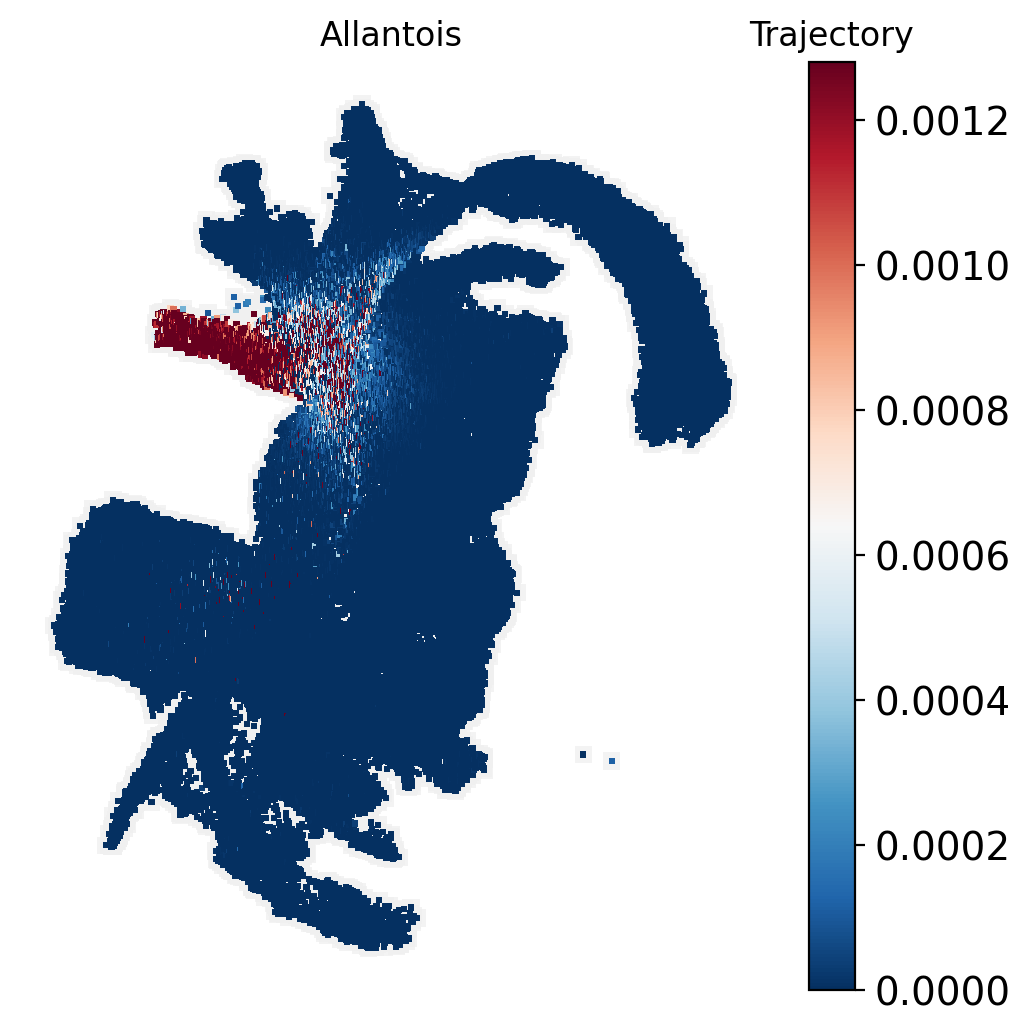

In [161]:
def update_trajectory_vis(name):
    figure = plt.figure(figsize=(5, 5))
    plt.axis('off')
    plt.tight_layout()
    plt.title(name)
    plt.scatter(adata.obs['umapX'], adata.obs['umapY'], c='#f0f0f0',
                   s=40, marker=',', edgecolors='none', alpha=0.8)
    binned_df = trajectory_ds.obs.copy()
    binned_df['values'] = trajectory_ds[:, name].X
    binned_df = binned_df.groupby(['umapX', 'umapY'], as_index=False).sum()
    plt.scatter(binned_df['umapX'], binned_df['umapY'], c=binned_df['values'],
                   s=5, marker=',', edgecolors='none', vmax=binned_df['values'].quantile(0.975))
    plt.colorbar().ax.set_title('Trajectory')

widgets.interact(update_trajectory_vis, name=trajectory_dropdown)

In [162]:
df = pd.DataFrame(trajectory_ds.X, index = trajectory_ds.obs_names, columns = trajectory_ds.var_names)

In [163]:
adata = adata[df.index].copy()

In [83]:
adata.write('procdata/adata_gastr_wot_new_ann.h5')

In [84]:
df.to_csv('./procdata/df_gastr_wot_day8_5.csv')

In [6]:
adata = sc.read('./procdata/adata_gastr_wot_new_ann.h5')
df = pd.read_csv('./procdata/df_gastr_wot_new_ann.csv')

In [367]:
pcs =  pd.read_csv('/rds/project/rds-SDzz0CATGms/users/mb2338/gata1/data_input/pcs_for_Marina.csv',index_col=0)

In [368]:
new_names = [name[6:] for name in pcs.index]

pcs.index = new_names

In [369]:
pcs = pcs.loc[adata.obs_names]

In [370]:
adata.obsm['X_pca'] = pcs.values


In [371]:
adata.obsm['X_umap'] = np.stack([np.array(adata.obs.umapX).T,np.array(adata.obs.umapY)],axis=1)

In [372]:
df[meta.stage == 'E8.5']

/tmp/ipykernel_2365730/2122049749.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[meta.stage == 'E8.5']


,Allantois,Blood progenitors 1,Blood progenitors 2,Cardiomyocytes,Caudal Mesoderm,Caudal epiblast,Caudal neurectoderm,Def. endoderm,Endothelium,Erythroid1,...,NMP,Notochord,PGC,Paraxial mesoderm,Pharyngeal mesoderm,Rostral neurectoderm,Somitic mesoderm,Spinal cord,Surface ectoderm,Visceral endoderm
cell_36865,8.725699e-07,1.333715e-05,6.626420e-07,2.222845e-07,5.131787e-06,5.026599e-05,1.234733e-04,7.671411e-06,6.082732e-09,1.597981e-10,...,9.162241e-06,3.614821e-08,1.227343e-07,7.647847e-05,4.762425e-05,2.509803e-04,9.162627e-06,1.426178e-04,4.915142e-05,1.611984e-11
cell_36866,3.810280e-04,2.081285e-07,1.414786e-08,2.930799e-06,1.140135e-09,8.231461e-10,2.893158e-10,8.264718e-07,8.194421e-10,3.432310e-12,...,3.207801e-10,8.842478e-09,1.990968e-08,6.172110e-08,2.559934e-05,5.369371e-10,6.693523e-09,2.881702e-10,3.242563e-07,2.208413e-10
cell_36867,4.283650e-18,3.547897e-08,8.324609e-05,3.211553e-18,1.800386e-16,3.296841e-15,3.548726e-16,1.234529e-17,4.492078e-19,3.479752e-04,...,1.008640e-18,1.882688e-23,2.766791e-15,8.070084e-15,8.756875e-16,3.790706e-16,2.925961e-17,4.106465e-18,3.384965e-17,5.112988e-26
cell_36869,2.103651e-08,3.039259e-07,1.623769e-08,7.958540e-08,1.227383e-05,1.445384e-04,3.395373e-04,2.420417e-06,3.298884e-11,4.864391e-13,...,6.437926e-05,3.736363e-09,1.784361e-08,7.996297e-06,5.387447e-06,1.879665e-04,1.860078e-06,3.332074e-04,1.525444e-05,4.167433e-12
cell_36870,5.815514e-08,5.178669e-08,1.780424e-09,3.531720e-08,8.350695e-04,5.809733e-05,1.063061e-06,1.085068e-05,4.353501e-10,1.056832e-14,...,2.031313e-04,1.370267e-07,8.885051e-05,2.617993e-07,9.642876e-08,5.037308e-08,5.377958e-04,4.052770e-07,4.135175e-06,1.339093e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_139326,1.951493e-18,8.358182e-08,1.585804e-04,1.438633e-17,3.074347e-16,4.988046e-15,3.353839e-16,1.400660e-17,1.161418e-18,3.717009e-04,...,1.068624e-18,7.358802e-23,9.953877e-16,8.218899e-15,3.713504e-16,3.067854e-16,2.119684e-17,5.781325e-18,4.641116e-17,6.426462e-25
cell_139327,3.037631e-18,8.934710e-08,1.720828e-04,1.061908e-17,3.388179e-16,6.121394e-15,4.745540e-16,1.754858e-17,1.682323e-18,3.749601e-04,...,1.453146e-18,5.801532e-23,2.351867e-15,1.116591e-14,8.025694e-16,4.649792e-16,3.463226e-17,6.654532e-18,5.630317e-17,4.260582e-25
cell_139329,1.168985e-08,6.440761e-09,7.844279e-10,9.863255e-09,1.233674e-05,4.778705e-07,8.653264e-08,1.041140e-06,1.410071e-11,3.156829e-14,...,5.985030e-07,3.942842e-09,4.664090e-08,3.989669e-05,3.060849e-06,5.360252e-08,1.911876e-03,1.566324e-07,2.446628e-08,1.929541e-12
cell_139330,1.693185e-18,1.400055e-07,2.352825e-04,1.774240e-17,4.027658e-16,6.774744e-15,3.962164e-16,2.045189e-17,2.265422e-18,3.818814e-04,...,1.877533e-18,2.248524e-22,1.694202e-15,9.933107e-15,3.544847e-16,3.715147e-16,2.427087e-17,8.039966e-18,6.060847e-17,2.193662e-24


0.0001


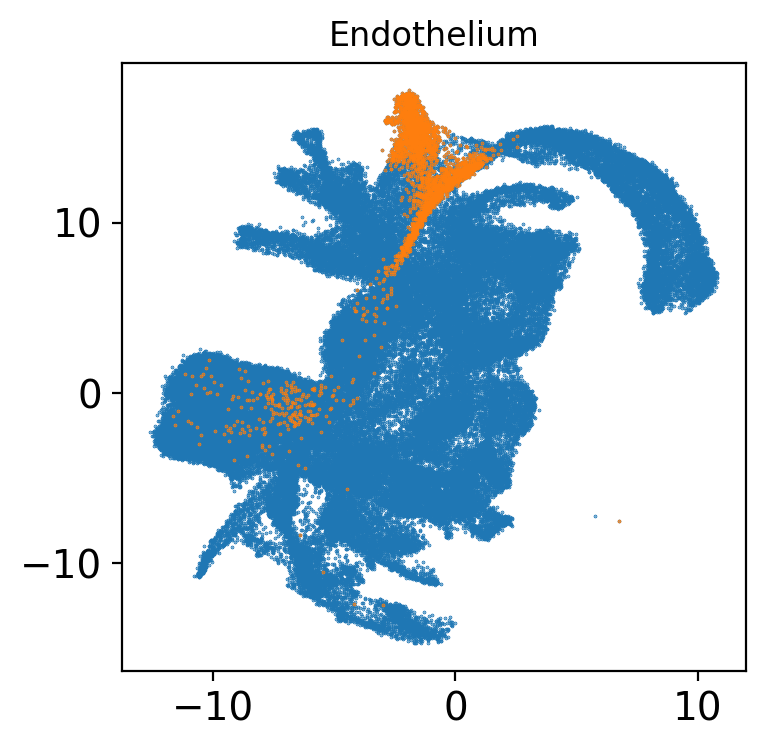

In [376]:
pops = ['Allantois', 
        'Erythroid3',
       'Endothelium',
       'Cardiomyocytes']

dict_pop = {
  "Allantois": 0.0001,
    "Erythroid3": 0.000001,
    "Endothelium": 0.0001,
    "Cardiomyocytes": 0.00001}

for pop in pops[2:3]:

    thr = dict_pop[pop]
   # thr =0.000001
#     thr = np.quantile(df[pop],0.9)
    print(thr)
    vec = np.array(df[pop]>thr) 


    plt.scatter(adata.obs.umapX, adata.obs.umapY,s = .1)
    plt.scatter(adata[vec,:].obs.umapX, adata[vec,:].obs.umapY,s = .1)
    plt.title(pop)
    plt.show()

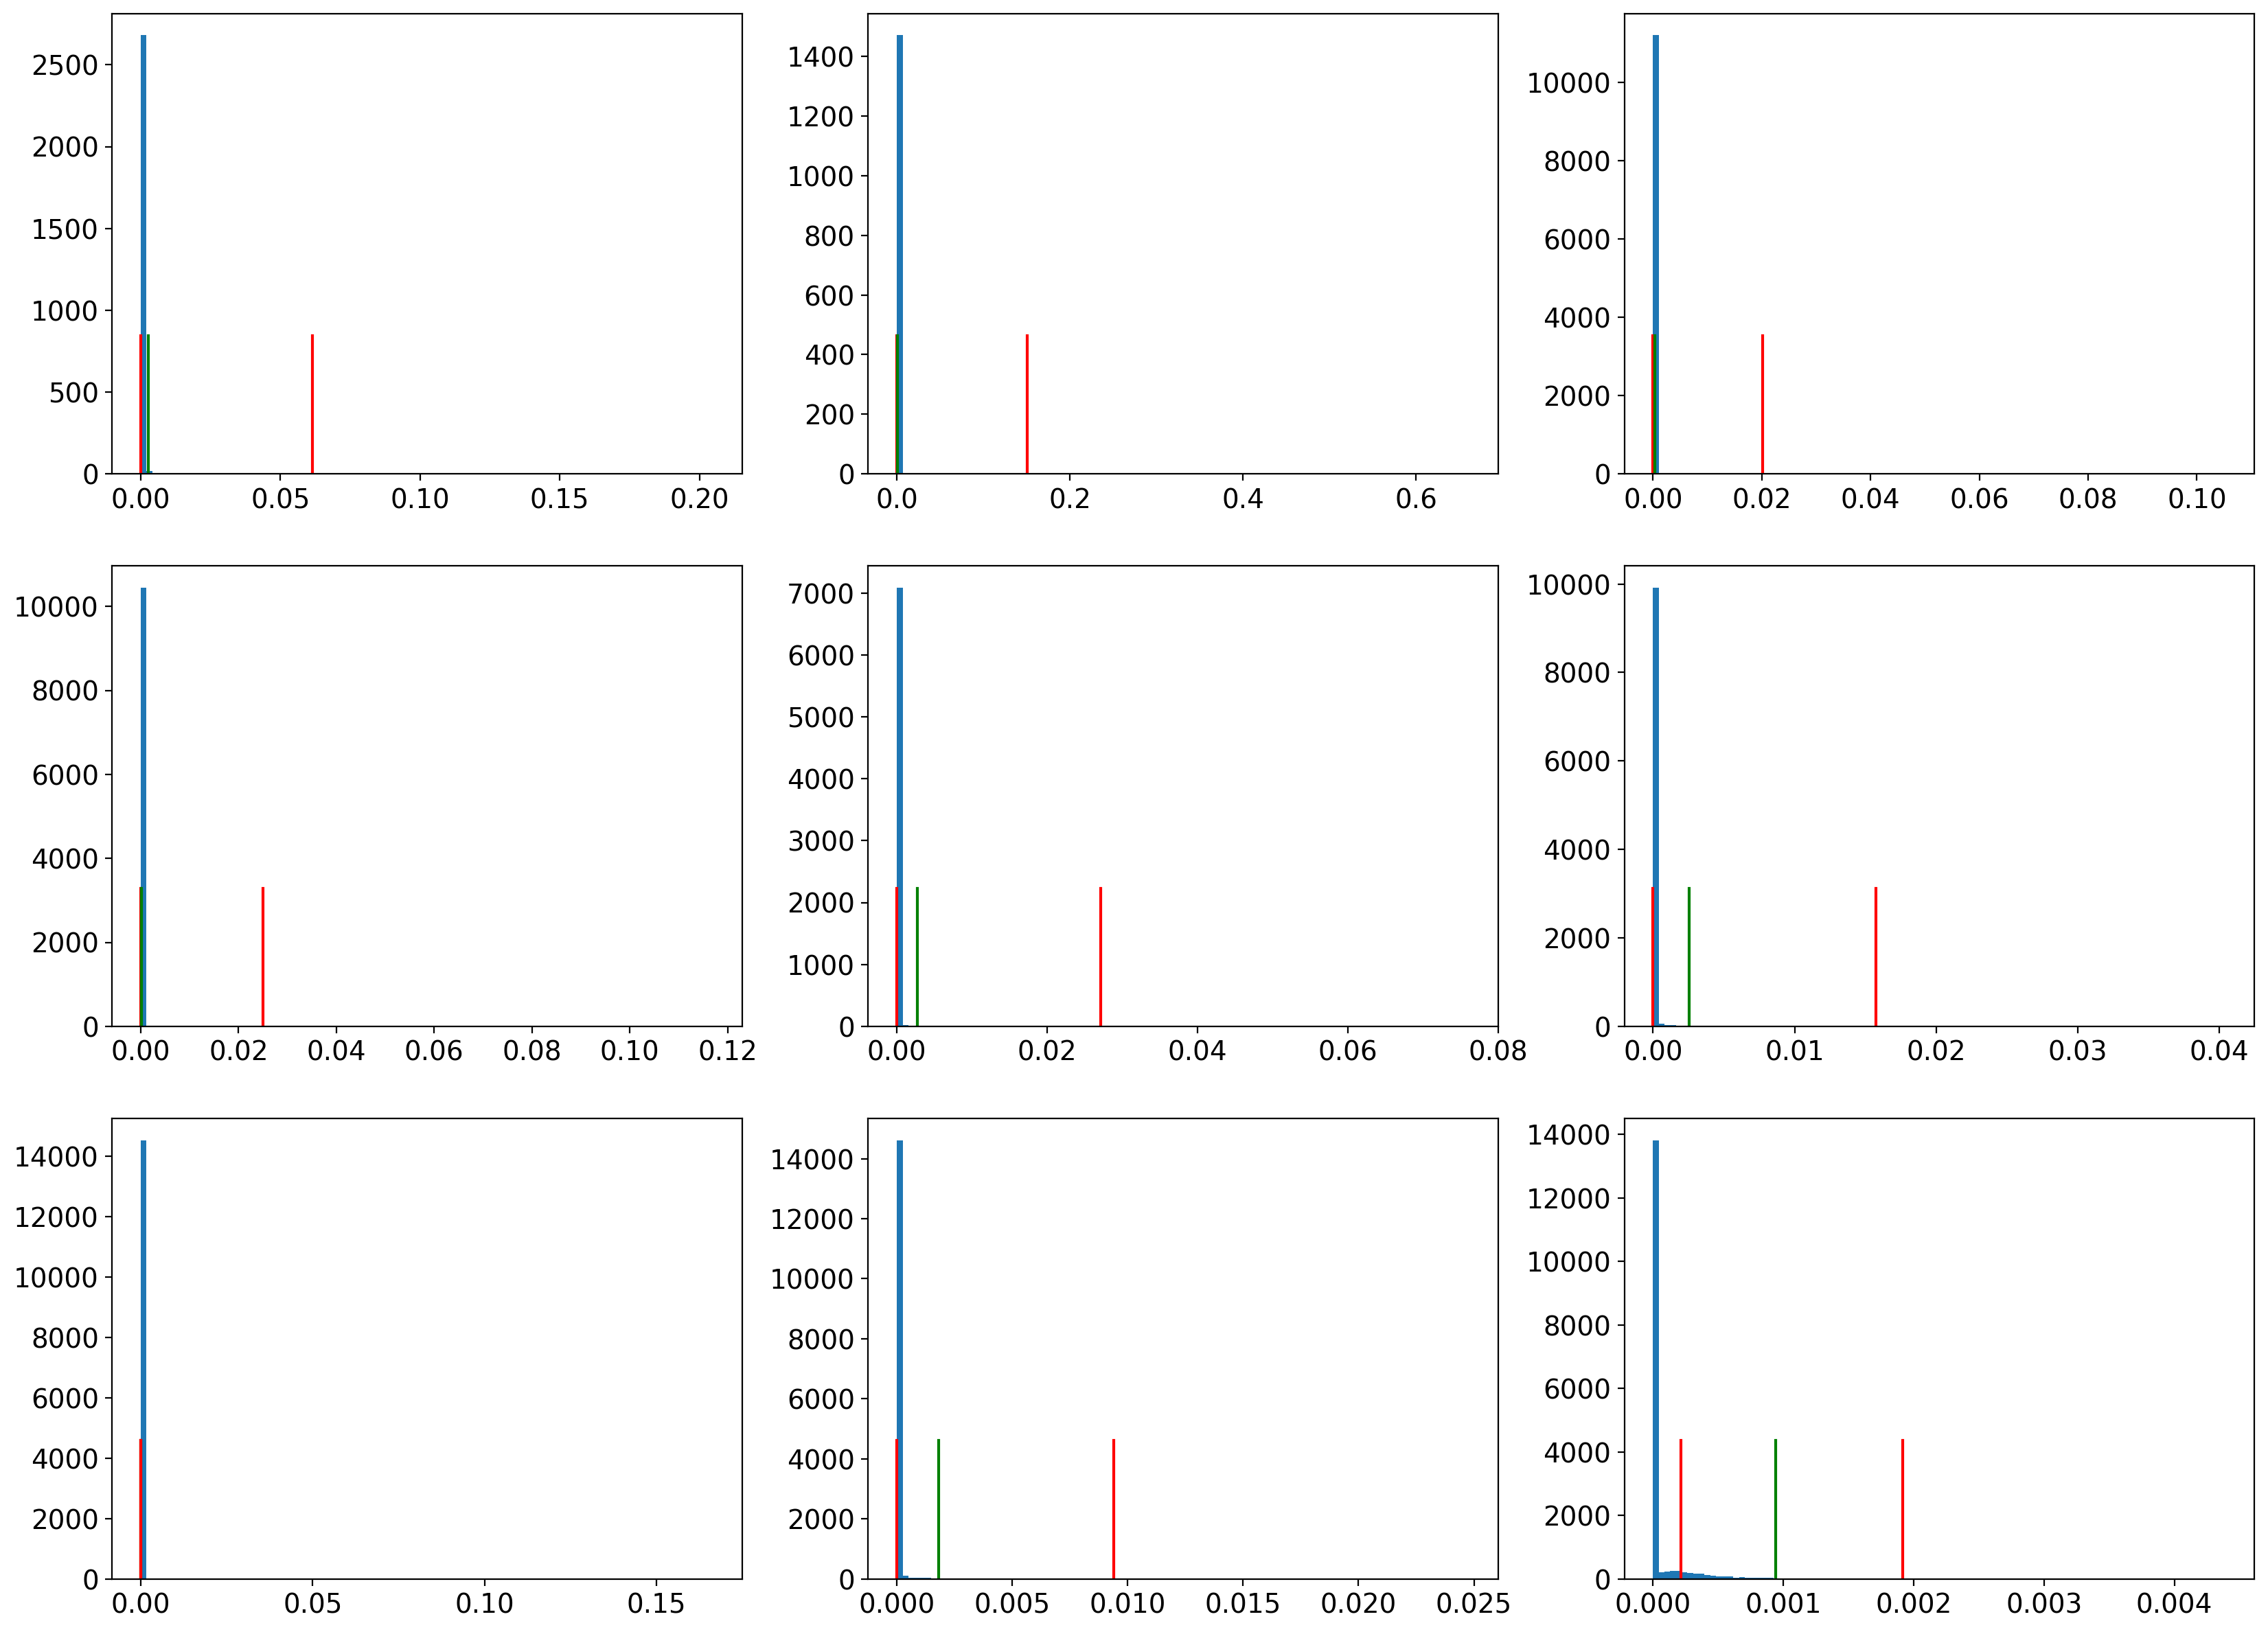

In [378]:
for cluster in pops[1:2]:
 
    fig, axs = plt.subplots(3, 3,figsize = (20,15))
 
    k = -1
    for time in ['E6.5','E6.75','E7.0','E7.25','E7.5','E7.75','E8.0','E8.25','E8.5']:
 
        k+=1
 
        vec_time = np.array(adata.obs['stage'] == time)
 
        to_hist = np.array(df.loc[vec_time][cluster])
 
        threshold1 = np.quantile(to_hist,0.9)
        threshold2 = np.quantile(to_hist,0.99)
 
        threshold3 = np.quantile(to_hist,0.999)
 
 
 
        axs[int(np.floor(k/3)),np.mod(k,3)].hist(to_hist,bins=100)
 
        axs[int(np.floor(k/3)),np.mod(k,3)].axvline(x=threshold1,ymin= 0,ymax= 0.3,c='r')
        axs[int(np.floor(k/3)),np.mod(k,3)].axvline(x=threshold2,ymin= 0,ymax= 0.3,c='g')
 
        axs[int(np.floor(k/3)),np.mod(k,3)].axvline(x=threshold3,ymin= 0,ymax= 0.3,c='r')

In [400]:
time_all[5:]

['E7.75', 'E8.0', 'E8.25', 'E8.5']

In [401]:
time_all[5]

'E7.75'

... storing 'Allantois_cells' as categorical


E8.0
E8.25
E8.5


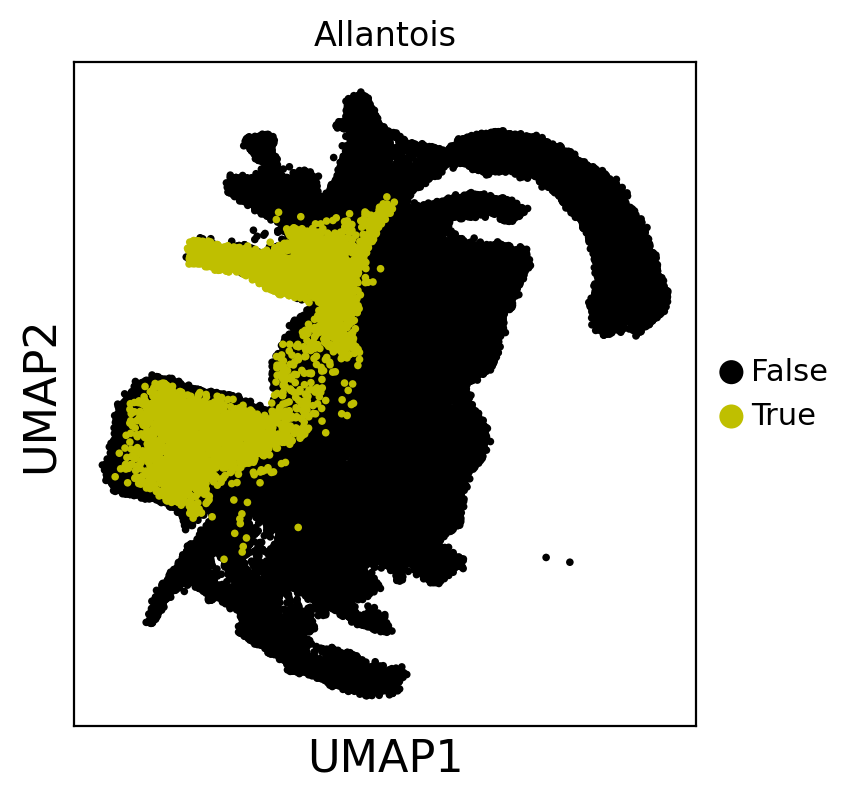

In [410]:
for cluster in pops[:1]:
 
 
    final_vec = np.array(['False' for i in range(adata.obs.shape[0])],dtype = 'str')
 
 
    time_all = ['E6.5','E6.75','E7.0','E7.25','E7.5','E7.75','E8.0','E8.25','E8.5']
#     bt = 3
    ##
    qq =0.5
    for time in time_all[:2]:
 
 
        vec_time = adata.obs['stage'] == time
 
        to_hist = np.array(df.loc[vec_time][cluster])
 
 
        threshold = np.quantile(to_hist,qq)
 
 
        final_vec[vec_time] = to_hist>=threshold
 
    qq = 0.95
    vec_time = adata.obs['stage'] ==  time_all[2]

    to_hist = np.array(df.loc[vec_time][cluster])


    threshold = np.quantile(to_hist,qq)


    final_vec[vec_time] = to_hist>=threshold
    ##    
    qq =0.98
    vec_time = adata.obs['stage'] ==  time_all[3]

    to_hist = np.array(df.loc[vec_time][cluster])


    threshold = np.quantile(to_hist,qq)


    final_vec[vec_time] = to_hist>=threshold
    
    qq = 0.95
    vec_time = adata.obs['stage'] == time_all[4]

    to_hist = np.array(df.loc[vec_time][cluster])


    threshold = np.quantile(to_hist,qq)


    final_vec[vec_time] = to_hist>=threshold

    qq =0.92
    vec_time = adata.obs['stage'] == time_all[5]

    to_hist = np.array(df.loc[vec_time][cluster])


    threshold = np.quantile(to_hist,qq)


    final_vec[vec_time] = to_hist>=threshold 
        
    qq =0.001
    for time in time_all[6:]:
 
 
        print(time)
 
        vec_time = adata.obs['stage'] == time
 
        to_hist = np.array(df.loc[vec_time][cluster])
 
 
        threshold = np.quantile(to_hist,qq)
 
 
        final_vec[vec_time] = to_hist>=qq
    ##
 
    adata.obs[cluster  + '_cells' ] = final_vec
 
#     sc.pl.scatter(adata,basis='umap',color = 'new_ann',groups = [cluster], size = 30,palette=['k','y'],title = cluster)
#     sc.pl.scatter(adata,basis='umap',color = [cluster  + '_cells'], size = 30,palette=['k','y'],title = cluster)
 
 
    #sc.pl.scatter(adata,basis='umap',color = 'new_ann',groups = [cluster], size = 30,palette=['k'],title = cluster)     
    sc.pl.scatter(adata,basis='umap',color = [cluster  + '_cells'], size = 30,palette=['k','y'],title = cluster)

In [362]:
vec

array([False,  True,  True, ..., False, False, False])

In [363]:
final_vec

array(['False', 'True', 'False', ..., 'False', 'False', 'False'],
      dtype='<U5')

In [365]:
adata_ery = adata[vec].copy()

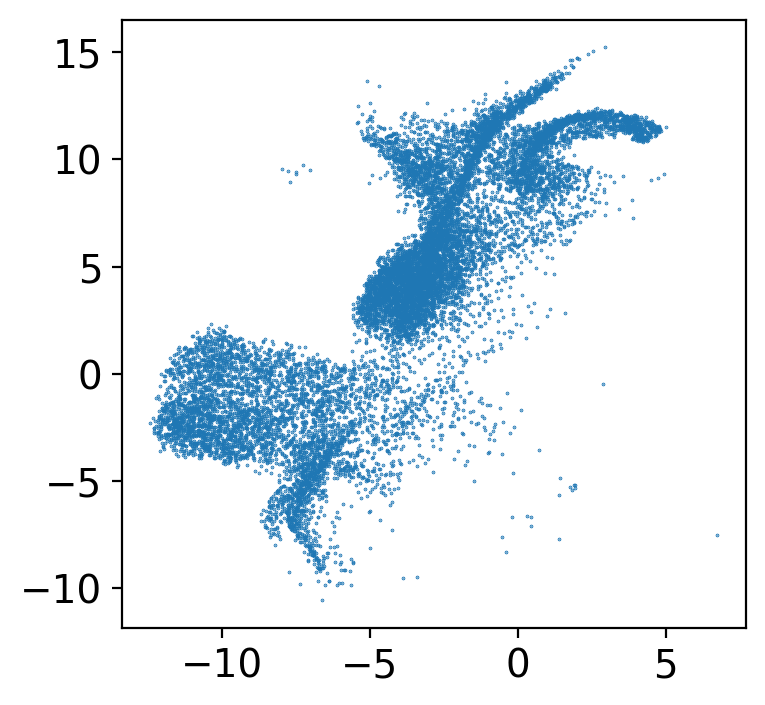

In [361]:
plt.scatter(adata_ery.obs.umapX, adata_ery.obs.umapY,s = .1)


In [193]:
adata_ery.obs.columns

Index(['cell', 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler',
       'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage',
       'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY',
       'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX',
       'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX',
       'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'new_ann'],
      dtype='object')

In [448]:
adata.uns['iroot'] = np.flatnonzero((adata.obs['stage']  == 'E6.5') & (adata.obs['celltype']  == 'Epiblast'))[0]
sc.pp.neighbors(adata)
sc.tl.diffmap(adata)
sc.tl.dpt(adata)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9996239  0.9983577  0.9971649  0.99634236 0.99518865
     0.9948261  0.99451953 0.99435604 0.99412006 0.99192744 0.9913214
     0.9903483  0.98851204 0.98770905]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:12)
computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


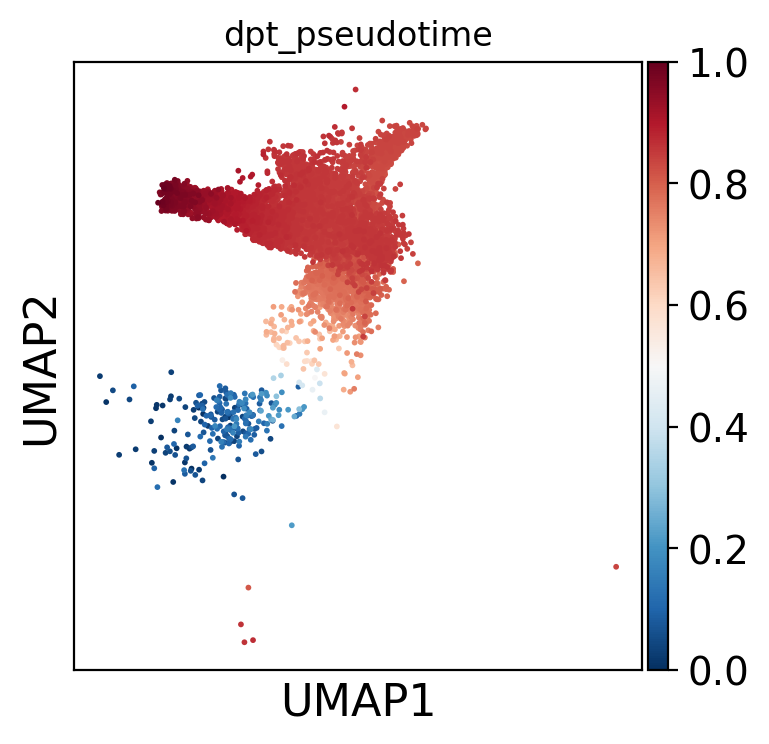

In [196]:
sc.pl.umap(adata,color ='dpt_pseudotime')

In [427]:

import cellrank as cr
from cellrank.tl.kernels import CytoTRACEKernel

sc.pp.neighbors(adata, n_neighbors=12, use_rep='X_pca')
adata.layers["spliced"] = adata.X
adata.layers["unspliced"] = adata.X
scv.pp.moments(adata, n_pcs=30, n_neighbors=30, use_rep='X_pca')

ctk = CytoTRACEKernel(adata)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
Normalized count data: X.
computing neighbors
    finished (0:00:13) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:02:17) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
Computing CytoTRACE score with `31217` genes
Adding `adata.obs['ct_score']`
       `adata.obs['ct_pseudotime']`
       `adata.obs['ct_num_exp_genes']`
       `adata.var['ct_gene_corr']`
       `adata.var['ct_correlates']`
       `adata.uns['ct_params']`
    Finish (0:00:12)


In [ ]:
cellrank

In [440]:
cellrank.cellrank

<module 'cellrank' from '/usr/local/lib/python3.8/dist-packages/cellrank/__init__.py'>

In [428]:
ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)

Computing transition matrix based on `ct_pseudotime`


  0%|          | 0/94931 [00:00<?, ?cell/s]

    Finish (0:00:48)


<CytoTRACEKernel>

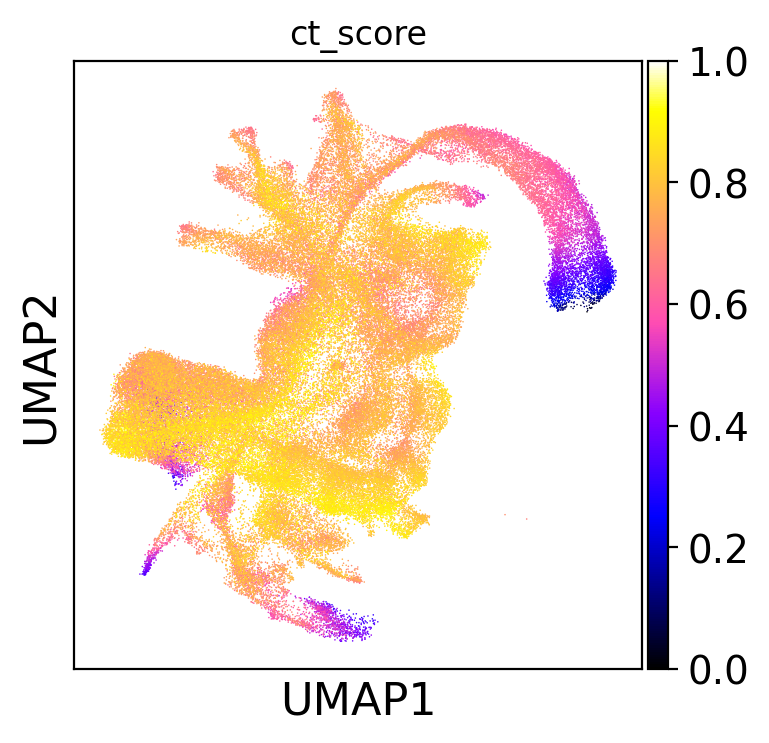

In [445]:
sc.pl.embedding(
    adata,
    color=["ct_score"],
    basis="umap",
    color_map="gnuplot2",
)

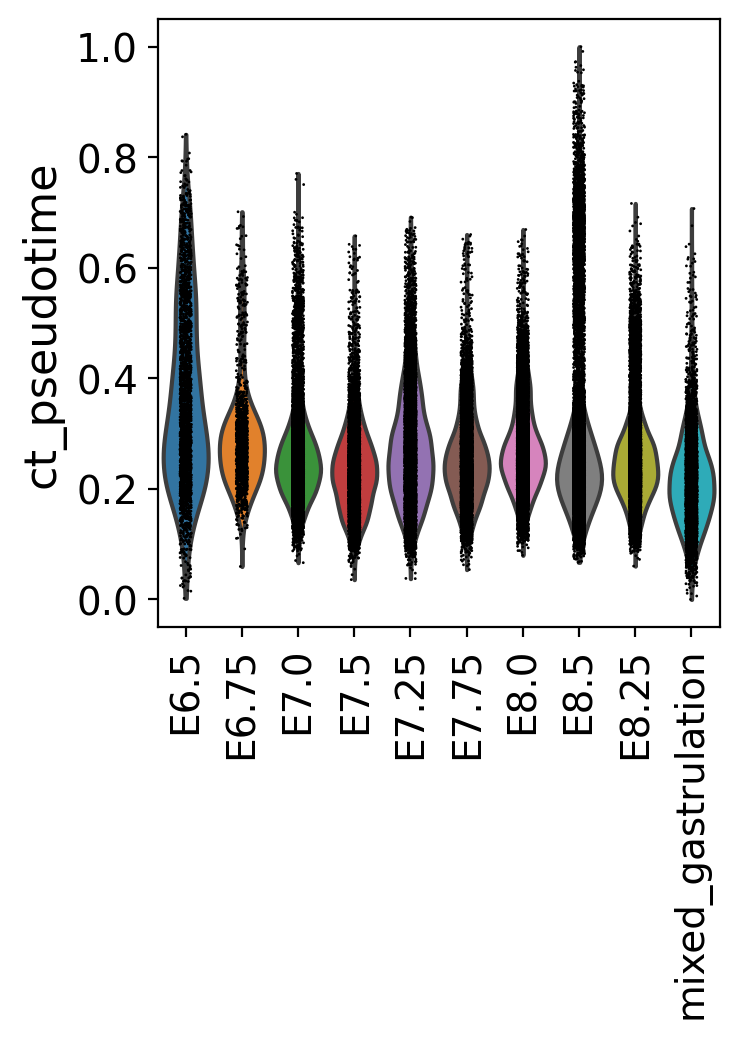

In [447]:
sc.pl.violin(adata, keys=["ct_pseudotime"], groupby="stage", rotation=90)

Simulating `5` random walks of maximum length `23733`


  0%|          | 0/5 [00:00<?, ?sim/s]

    Finish (0:02:01)
Plotting random walks


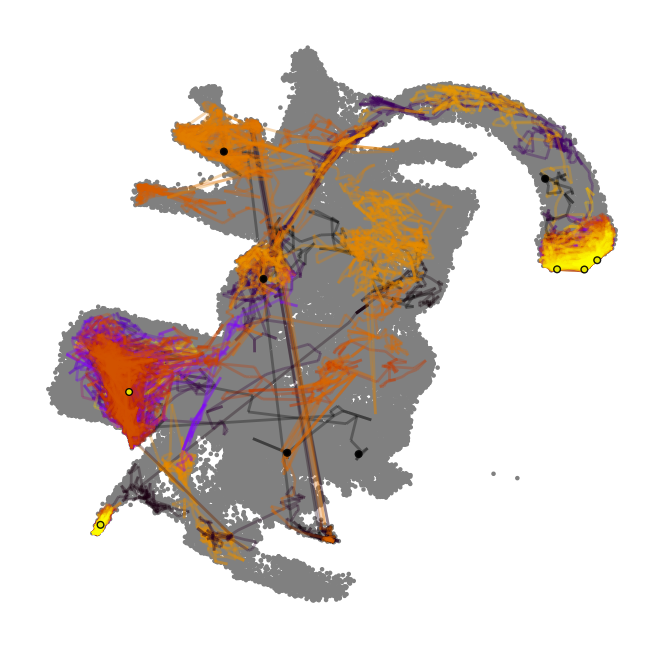

In [432]:
ctk.plot_random_walks(n_sims = 5)